# Spotify Music Recommendation and Customer Segmentation

## Project Brief

This project explores the Spotify Tracks Dataset to develop machine learning solutions for music recommendation and customer segmentation. The notebook follows the complete data science workflow required in the assignment, from understanding and preparing the data to building recommendation and clustering models.

### Assignment Requirements

The project addresses the following objectives:

- Data and business understanding
- Data loading
- Data preparation
- Data cleaning
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Data modelling
  - Content-based recommendation
  - Collaborative recommendation
  - Hybrid recommendation
  - K-Means clustering
  - Gaussian Mixture Models (GMM)
  - Hierarchical clustering
- Model evaluation, recommendations, and documentation

# Business Understanding

Music streaming platforms contain millions of tracks, making it increasingly difficult for users to discover songs they are likely to enjoy. Recommendation systems help improve user experience by suggesting relevant music based on listening behaviour or song characteristics, while segmentation techniques help identify groups of similar songs that can support playlist generation, catalog organization, and recommendation strategies.

In this project, Spotify track metadata is used to investigate how audio characteristics can be leveraged to build recommendation systems and identify natural clusters of songs. The analysis focuses on understanding the dataset, preparing reliable features, and comparing different machine learning approaches before making recommendations.

### Data Scope and a Key Limitation

This dataset contains track-level metadata and audio features only --> it does not contain any user listening history, ratings, or interactions. This has a direct consequence for the modelling approach:

- **Content-based filtering** can be built directly from this data, since it only requires comparing tracks to each other by audio features.
- **Collaborative filtering** normally requires a user-item interaction matrix, which does not exist here. To demonstrate this technique, a set of synthetic users and simulated listening interactions will be generated based on plausible genre/mood preferences. This is a deliberate prototyping decision, disclosed here, and any collaborative filtering results should be read as a proof of concept rather than a validation on real user behaviour.
- **Hybrid filtering** inherits this same limitation, since it blends the two signals above.

### What Success Looks Like

Each modelling approach is judged against a different practical standard, reflecting what a streaming product team would actually care about:

- **Content-based recommendation**: recommended tracks should be audibly/stylistically similar to the seed track, a listener should recognise *why* a track was suggested.
- **Collaborative recommendation**: recommended tracks should surface less obvious, cross-genre matches that simulated users with similar taste patterns responded to --> value here is in discovery, not obvious similarity.
- **Hybrid recommendation**: should balance both --> neither signal should dominate to the point of duplicating the other approach's output.
- **K-Means / GMM / Hierarchical segmentation**: clusters should be interpretable and actionable --> e.g., usable for playlist generation or catalog organisation -- rather than optimal only by an internal metric (inertia, BIC, silhouette) with no human-readable story behind the grouping.

In [ ]:
# imports
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Machine Learning utilities
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel
from sklearn.metrics.pairwise import cosine_similarity
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split, cross_validate
from surprise import accuracy
from collections import defaultdict
# import warnings
# warnings.filterwarnings("ignore")

# Data Loading & Understanding

The dataset is loaded into a Pandas DataFrame before inspecting its overall structure, data types, missing values, duplicate records, and summary statistics.

### Initial Dataset Inspection

Before preparing the data, it is important to understand its overall structure. This initial inspection provides information about the dataset size, data types, and numerical feature distributions without making any modifications.

The goal at this stage is to identify potential quality issues that may require cleaning or preprocessing later in the workflow.

In [ ]:

df = pd.read_csv("spotify-tracks-dataset.csv")

print(df.head())
print("Shape: ", df.shape)
print("duplicated: ", df.duplicated().sum())
print(df.describe()) # identify variables that may require closer inspection during data cleaning.
df.info()

   Unnamed: 0.1  Unnamed: 0                track_id                 artists  \
0             0           0  5SuOikwiRyPMVoIQDJUgSV             Gen Hoshino   
1             1           1  4qPNDBW1i3p13qLCt0Ki3A            Ben Woodward   
2             2           2  1iJBSr7s7jYXzM8EGcbK5b  Ingrid Michaelson;ZAYN   
3             3           3  6lfxq3CG4xtTiEg7opyCyx            Kina Grannis   
4             4           4  5vjLSffimiIP26QG5WcN2K        Chord Overstreet   

                                          album_name  \
0                                             Comedy   
1                                   Ghost (Acoustic)   
2                                     To Begin Again   
3  Crazy Rich Asians (Original Motion Picture Sou...   
4                                            Hold On   

                   track_name  popularity  duration_ms  explicit  \
0                      Comedy          73       230666     False   
1            Ghost - Acoustic          55       1496

## Missing Value Assessment

Missing values can reduce model performance and may require different treatment depending on the affected feature.

This inspection identifies which variables contain missing information before deciding whether records should be removed or values imputed.

In [ ]:
missing = df.isnull().sum().sort_values(ascending=False)
print(missing)
print(df[df["artists"].isnull() | df["album_name"].isnull() | df["track_name"].isnull()]) # to expose the one null row

artists             1
album_name          1
track_name          1
Unnamed: 0.1        0
mode                0
time_signature      0
tempo               0
valence             0
liveness            0
instrumentalness    0
acousticness        0
speechiness         0
key                 0
loudness            0
Unnamed: 0          0
energy              0
danceability        0
explicit            0
duration_ms         0
popularity          0
track_id            0
track_genre         0
dtype: int64
       Unnamed: 0.1  Unnamed: 0                track_id artists album_name  \
65900         65900       65900  1kR4gIb7nGxHPI3D2ifs59     NaN        NaN   

      track_name  popularity  duration_ms  explicit  danceability  ...  \
65900        NaN           0            0     False         0.501  ...   

       loudness  mode  speechiness  acousticness  instrumentalness  liveness  \
65900     -9.46     0       0.0605          0.69           0.00396    0.0747   

       valence    tempo  time_signat

## Verifying the Primary Identifier

The dataset documentation states that `track_id` uniquely identifies each Spotify track. Before cleaning the data, this assumption should be verified.

This inspection answers three questions:

- Is each `track_id` unique?
- If duplicate IDs exist, are they exact duplicates or do they contain different information?
- Should duplicate records be removed or consolidated?

Understanding the nature of duplicate track IDs is important because recommendation systems should compare unique songs rather than multiple copies of the same song.

In [42]:
print("duplicates in trac_id: ", df["track_id"].duplicated().sum())
print("not unique: ", df["track_id"].nunique())
print(df[df["track_id"].duplicated(keep=False)].sort_values("track_id").head(10))

duplicates in trac_id:  24259
not unique:  89741
        Unnamed: 0.1  Unnamed: 0                track_id  \
15028          15028       15028  001APMDOl3qtx1526T11n1   
103211        103211      103211  001APMDOl3qtx1526T11n1   
85578          85578       85578  001YQlnDSduXd5LgBd66gT   
100420        100420      100420  001YQlnDSduXd5LgBd66gT   
91801          91801       91801  003vvx7Niy0yvhvHt4a68B   
3257            3257        3257  003vvx7Niy0yvhvHt4a68B   
2106            2106        2106  003vvx7Niy0yvhvHt4a68B   
33178          33178       33178  004h8smbIoAkUNDJvVKwkG   
94239          94239       94239  004h8smbIoAkUNDJvVKwkG   
97533          97533       97533  006rHBBNLJMpQs8fRC2GDe   

                             artists                       album_name  \
15028              Pink Sweat$;Kirby                          New RnB   
103211             Pink Sweat$;Kirby                          New RnB   
85578                    Soda Stereo         Soda Stereo (Remastered)  

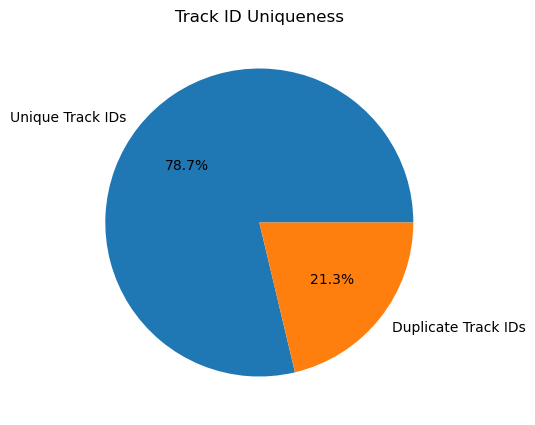

In [43]:
duplicate_count = df["track_id"].duplicated().sum()
unique_count = df["track_id"].nunique()

plt.figure(figsize=(5,5))

plt.pie(
    [unique_count, duplicate_count],
    labels=["Unique Track IDs","Duplicate Track IDs"],
    autopct="%1.1f%%"
)

plt.title("Track ID Uniqueness")
plt.show()

### Interpretation

Most tracks have unique identifiers, while a smaller proportion appears multiple times. Inspecting these duplicate records helps determine whether they are redundant copies or represent the same song assigned to multiple genres.

## Feature Types

Understanding the balance between numerical and categorical variables helps determine which preprocessing techniques will be required later.

Recommendation models primarily rely on numerical audio features, while metadata such as artist names and album titles provide descriptive information but are generally not used directly during modelling.

In [44]:
df.dtypes.value_counts()

float64    9
int64      7
object     5
bool       1
Name: count, dtype: int64

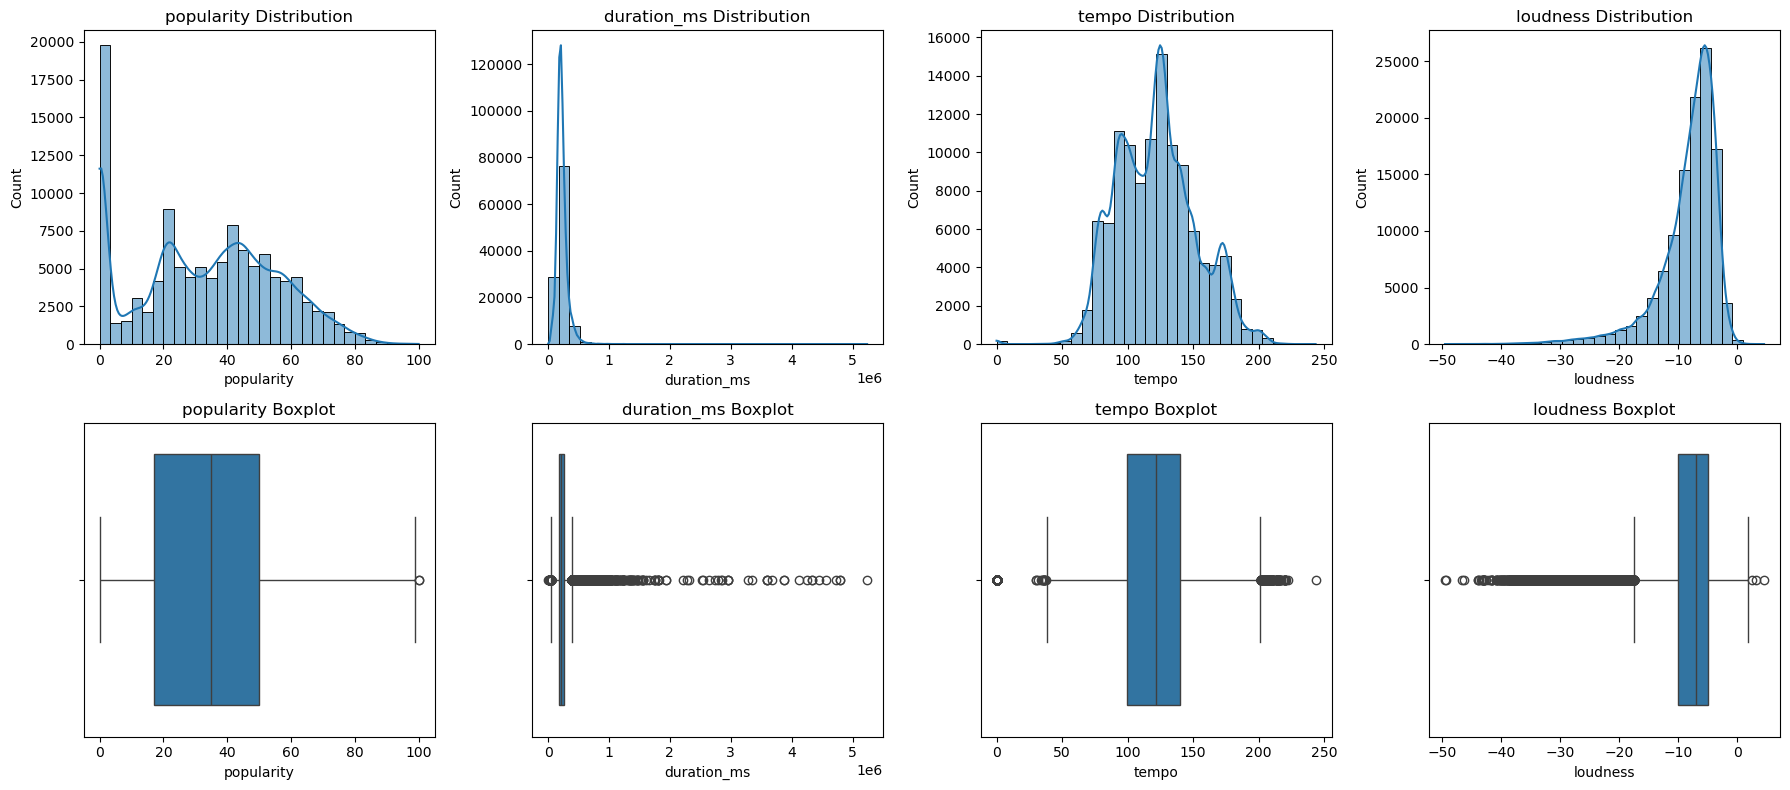

In [46]:
# Numerical features selected for initial inspection
numeric_cols = [
    "popularity",
    "duration_ms",
    "tempo",
    "loudness"
]

# Create a 2 × 4 grid:
# Top row -> Histograms
# Bottom row -> Boxplots

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(numeric_cols):
    # Histogram
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True,
        ax=axes[0, i]
    )
    axes[0, i].set_title(f"{col} Distribution")
    axes[0, i].set_xlabel(col)

    # Boxplot
    sns.boxplot(
        x=df[col],
        ax=axes[1, i]
    )
    axes[1, i].set_title(f"{col} Boxplot")
    axes[1, i].set_xlabel(col)

plt.tight_layout()
plt.show()

### Interpretation

The histograms and boxplots provide an initial view of the numerical feature distributions.

- **Popularity** appears to be moderately right-skewed, indicating that relatively few tracks achieve very high popularity.
- **Duration** shows several extreme values that may represent unusually long recordings or data anomalies and should be investigated during data cleaning.
- **Tempo** is concentrated within a realistic range for most songs, although a few extreme observations are visible.
- **Loudness** follows a relatively consistent distribution with only a small number of potential outliers.

At this stage, no observations are removed. These visualizations serve to identify features that require closer inspection during the data cleaning phase.

In [50]:
print("key = -1 count:", (df["key"] == -1).sum())

key = -1 count: 0


No missing key values were found. A small number of tracks (16 under 30s, 153 over 15min) are outliers in duration but represent a negligible fraction of the dataset (<0.2%) and are retained as plausible short interludes/long mixes rather than treated as errors

In [51]:
print(df["duration_ms"].describe())
print("Tracks under 30s:", (df["duration_ms"] < 30000).sum())
print("Tracks over 15min:", (df["duration_ms"] > 900000).sum())

count    1.139990e+05
mean     2.280312e+05
std      1.072961e+05
min      8.586000e+03
25%      1.740660e+05
50%      2.129060e+05
75%      2.615060e+05
max      5.237295e+06
Name: duration_ms, dtype: float64
Tracks under 30s: 16
Tracks over 15min: 153


## Data Cleaning

In [49]:
# removing the single row with nulls
df = df.dropna(subset=["artists", "album_name", "track_name"])

In [47]:
df_clean = (
    df.drop(columns=["Unnamed: 0", "Unnamed: 0.1"])
      .groupby("track_id", as_index=False)
      .agg({
          "artists": "first",
          "album_name": "first",
          "track_name": "first",
          "popularity": "first",
          "duration_ms": "first",
          "explicit": "first",
          "danceability": "first",
          "energy": "first",
          "key": "first",
          "loudness": "first",
          "mode": "first",
          "speechiness": "first",
          "acousticness": "first",
          "instrumentalness": "first",
          "liveness": "first",
          "valence": "first",
          "tempo": "first",
          "time_signature": "first",
          "track_genre": lambda x: sorted(set(x)),
      })
)
df_clean.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0000vdREvCVMxbQTkS888c,Rill,Lolly,Lolly,44,160725,True,0.910,0.374,8,-9.844,0,0.1990,0.075700,0.00301,0.1540,0.432,104.042,4,[german]
1,000CC8EParg64OmTxVnZ0p,Glee Cast,Glee Love Songs,It's All Coming Back To Me Now (Glee Cast Vers...,47,322933,False,0.269,0.516,0,-7.361,1,0.0366,0.406000,0.00000,0.1170,0.341,178.174,4,[club]
2,000Iz0K615UepwSJ5z2RE5,Paul Kalkbrenner;Pig&Dan,X,Böxig Leise - Pig & Dan Remix,22,515360,False,0.686,0.560,5,-13.264,0,0.0462,0.001140,0.18100,0.1110,0.108,119.997,4,[minimal-techno]
3,000RDCYioLteXcutOjeweY,Jordan Sandhu,Teeje Week,Teeje Week,62,190203,False,0.679,0.770,0,-3.537,1,0.1900,0.058300,0.00000,0.0825,0.839,161.721,4,[hip-hop]
4,000qpdoc97IMTBvF8gwcpy,Paul Kalkbrenner,Zeit,Tief,19,331240,False,0.519,0.431,6,-13.606,0,0.0291,0.000964,0.72000,0.0916,0.234,129.971,4,[minimal-techno]


In [52]:
assert df_clean["track_id"].nunique() == len(df_clean)
print(df_clean.shape)  # expect (89741 or 89740 after null-drop, 19)
print(df_clean["track_genre"].apply(len).value_counts().head())  # how many tracks have multiple genre tags

(89741, 20)
track_genre
1    73442
2    11424
3     2955
4     1361
5      431
Name: count, dtype: int64


Deduplication reduced the dataset from 114,000 rows to 89,741 unique tracks. Of these, 73,442 carry a single genre tag while the remainder are cross-tagged across up to 5 genres, which will be preserved as a list rather than collapsed to one label

# Exploratory Data Analysis (EDA)

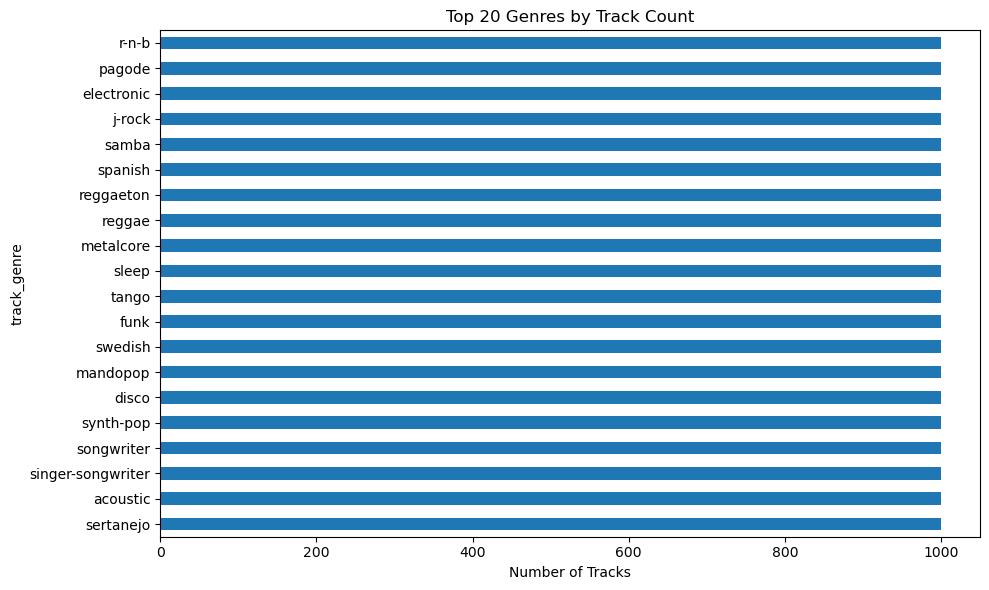

In [53]:
top_genres = df_clean["track_genre"].explode().value_counts().head(20) # track_genre is now a list per track, .explode() unpacks it so multi-genre tracks count toward each genre they're tagged with 

plt.figure(figsize=(10,6))
top_genres.plot(kind="barh")
plt.xlabel("Number of Tracks")
plt.title("Top 20 Genres by Track Count")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()